Day 11 Linear Regression

In [11]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [2]:
# House price dataset

data = {
    "Area": [1000, 1200, 1500, 1800, 2000, 2200, 2500],
    "Bedrooms": [2, 2, 3, 3, 4, 4, 5],
    "Age": [20, 15, 10, 8, 5, 3, 1],
    "Price": [200000, 250000, 320000, 400000, 500000, 600000, 700000]
}

df = pd.DataFrame(data)

print("Dataset:")
print(df)

Dataset:
   Area  Bedrooms  Age   Price
0  1000         2   20  200000
1  1200         2   15  250000
2  1500         3   10  320000
3  1800         3    8  400000
4  2000         4    5  500000
5  2200         4    3  600000
6  2500         5    1  700000


In [3]:
# Input features
X = df.drop("Price", axis=1)

# Output target
y = df["Price"]

print("Features:")
print(X)

print("\nTarget:")
print(y)

Features:
   Area  Bedrooms  Age
0  1000         2   20
1  1200         2   15
2  1500         3   10
3  1800         3    8
4  2000         4    5
5  2200         4    3
6  2500         5    1

Target:
0    200000
1    250000
2    320000
3    400000
4    500000
5    600000
6    700000
Name: Price, dtype: int64


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (5, 3)
Testing Data: (2, 3)


In [5]:
# Create model
model = LinearRegression()

# Train model
model.fit(
    X_train,
    y_train
)

print("Model trained successfully")

Model trained successfully


In [6]:
print("Intercept:")
print(model.intercept_)

print("\nCoefficients:")
for feature, coefficient in zip(
    X.columns,
    model.coef_
):
    print(feature, ":", coefficient)

Intercept:
296341.46341463435

Coefficients:
Area : 151.21951219512187
Bedrooms : 9024.39024390245
Age : -23902.439024390264


In [7]:
y_pred = model.predict(X_test)

print("Predicted Prices:")
print(y_pred)

print("\nActual Prices:")
print(y_test.values)

Predicted Prices:
[-12439.02439024 137317.07317073]

Actual Prices:
[200000 250000]


In [8]:
# Mean Absolute Error
mae = mean_absolute_error(
    y_test,
    y_pred
)

# Mean Squared Error
mse = mean_squared_error(
    y_test,
    y_pred
)

# Root Mean Squared Error
rmse = np.sqrt(mse)

# R2 Score
r2 = r2_score(
    y_test,
    y_pred
)


print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 162560.9756097563
MSE: 28913890541.344513
RMSE: 170040.84962544887
R2 Score: -45.26222486615122


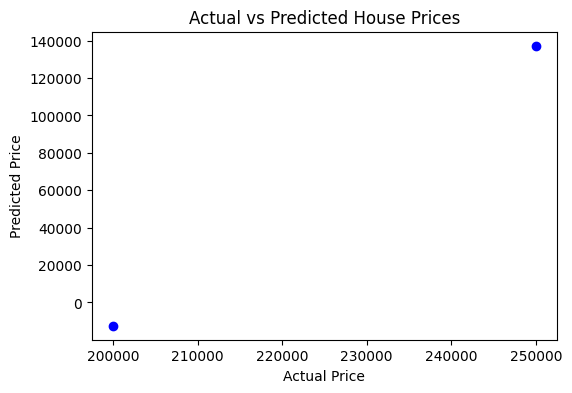

In [12]:
plt.figure(figsize=(6,4))

plt.scatter(
    y_test,
    y_pred,
    color="blue"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

In [13]:
# New house details:
# Area = 3000
# Bedrooms = 5
# Age = 2

new_house = pd.DataFrame({
    "Area": [3000],
    "Bedrooms": [5],
    "Age": [2]
})


prediction = model.predict(new_house)

print(
    "Predicted House Price:",
    prediction[0]
)

Predicted House Price: 747317.0731707317


Day 13 LOgistic Regression and Classification

Dataset Shape: (569, 30)
Target Classes: [0 1]
Accuracy: 0.956140350877193


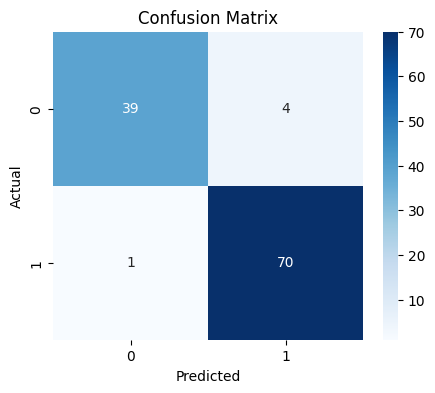


Classification Report
              precision    recall  f1-score   support

           0       0.97      0.91      0.94        43
           1       0.95      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

ROC-AUC Score: 0.9977071732721913


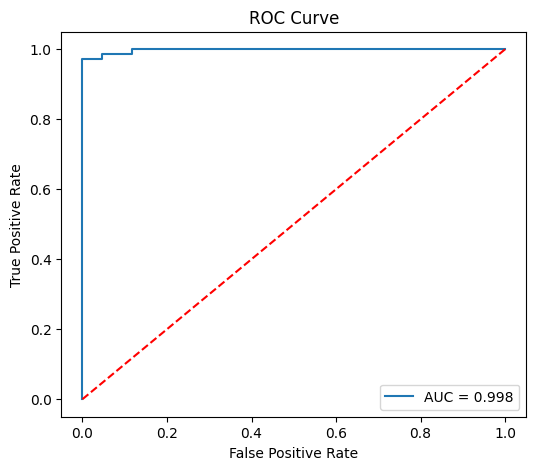

                    Feature  Coefficient
11            texture error     1.370567
0               mean radius     1.027437
1              mean texture     0.221451
20             worst radius     0.111653
15        compactness error     0.047361
3                 mean area     0.025467
19  fractal dimension error     0.011605
22          worst perimeter    -0.015554
23               worst area    -0.016857
14         smoothness error    -0.022455


In [14]:

# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

# Step 2: Load Dataset
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

print("Dataset Shape:", X.shape)
print("Target Classes:", np.unique(y))

# Step 3: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 4: Train Logistic Regression Model
model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

# Step 5: Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Step 6: Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Step 7: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Step 8: Classification Report
print("\nClassification Report")
print(classification_report(y_test, y_pred))

# Step 9: ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", roc_auc)

# Step 10: ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--', color='red')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# Step 11: Feature Coefficients
coef = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

print(coef.sort_values(by="Coefficient", ascending=False).head(10))

day 14 Decision trees and Random FOrests

In [15]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Decision Tree
dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))
print(classification_report(y_test, dt_pred))

# Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=3,
    random_state=42
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

# Feature Importance
print("Feature Importance:", rf.feature_importances_)

Decision Tree Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Random Forest Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Feature Importance: [0.10622642 0.00990277 0.45217545 0.43169535]


Day 15 SVM and KNN

In [16]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Load dataset
X, y = load_iris(return_X_y=True)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# SVM
svm = SVC(kernel="rbf")
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)

# KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, svm_pred))
print("KNN Accuracy:", accuracy_score(y_test, knn_pred))

SVM Accuracy: 1.0
KNN Accuracy: 1.0
